# 05 — Visualizations


## 1. Install packages

In [2]:
!pip install -q folktables shap lime scikit-learn pandas numpy matplotlib

## 2. Imports

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from folktables import ACSDataSource, ACSEmployment

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [4]:
from pathlib import Path

# save figures
FIGURE_DIR = Path("../figures")
if not FIGURE_DIR.parent.exists():
    FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POSTER_BLUE = "#0393DB"
POSTER_ORANGE = "#F26B21"
POSTER_GREEN = "#2E8B45"
POSTER_RED = "#D13F35"
POSTER_WHITE = "white"


## 3. Load the Folktables ACSEmployment dataset

The dataset has been downloaded directly through the `folktables` package and uses California as the default state.

In [5]:
# Load 2024 ACS person-level data for California

import pandas as pd
from folktables import ACSDataSource

data_source = ACSDataSource(
    survey_year="2024",
    horizon="1-Year",
    survey="person"
)

acs_data = data_source.get_data(states=["CA"], download=True)

# 2024 ACS
feature_map = {
    "AGEP": "age",
    "SCHL": "education",
    "MAR": "marital_status",
    "RELSHIPP": "relationship",
    "DIS": "disability",
    "ESP": "employment_status_parent",
    "CIT": "citizenship",
    "MIG": "mobility_status",
    "MIL": "military_service",
    "ANC": "ancestry",
    "NATIVITY": "nativity",
    "DEAR": "hearing_difficulty",
    "DEYE": "vision_difficulty",
    "DREM": "cognitive_difficulty",
    "SEX": "sex",
    "RAC1P": "race"
}

needed_cols = list(feature_map.keys()) + ["ESR"]

df = acs_data[needed_cols].copy()
df = df.rename(columns=feature_map)

# Convert ACS character-coded variables to numeric
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Restrict to working-age range for a labor-market analysis
df = df[(df["age"] >= 16) & (df["age"] <= 90)].copy()

# ESR = Employment Status Recode.
# Census codes:
# 1 = Civilian employed, at work
# 2 = Civilian employed, with a job but not at work
# 3 = Unemployed
# 4 = Armed forces, at work
# 5 = Armed forces, with a job but not at work
# 6 = Not in labor force
#
# For a broader "employed or has job" target:
df["employment"] = df["ESR"].isin([1, 2, 4, 5]).astype(int)

# Original Folktables ACSEmployment target:
# df["employment"] = (df["ESR"] == 1).astype(int)

df = df.drop(columns=["ESR"])

df.head()

,age,education,marital_status,relationship,disability,employment_status_parent,citizenship,mobility_status,military_service,ancestry,nativity,hearing_difficulty,vision_difficulty,cognitive_difficulty,sex,race,employment
0,45,7.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,9,0
1,45,14.0,3,37,1,NaN,1,3.0,4.0,1,1,2,2,1.0,1,3,0
2,21,20.0,5,38,2,NaN,1,1.0,4.0,1,1,2,2,2.0,2,8,1
3,28,18.0,1,37,2,NaN,1,3.0,4.0,1,1,2,2,2.0,1,8,0
4,19,18.0,5,38,2,NaN,1,3.0,4.0,1,1,2,2,2.0,2,6,0


## 5. Add readable labels for key auditing variables

For the this analysis, the variables of interest are **sex** and **race**.

The ACS sex variable is binary in this task:
- `1 = Male`
- `2 = Female`

Please note that binary encoding does not capture the full range of gender identity.

In [6]:
sex_map = {
    1: "Male",
    2: "Female"
}

race_map = {
    1: "White",
    2: "Black",
    3: "American Indian",
    4: "Alaska Native",
    5: "American Indian/Alaska Native - specified tribe",
    6: "Asian",
    7: "Native Hawaiian/Pacific Islander",
    8: "Other",
    9: "Two or more races"
}

citizenship_map = {
    1: "Born in U.S.",
    2: "Born in Puerto Rico / U.S. Island Areas",
    3: "Born abroad to U.S. parents",
    4: "U.S. citizen by naturalization",
    5: "Not a U.S. citizen"
}

df["sex_label"] = df["sex"].map(sex_map)
df["race_label"] = df["race"].map(race_map)
df["citizenship_label"] = df["citizenship"].map(citizenship_map)

df[["sex", "sex_label", "race", "race_label", "citizenship", "citizenship_label", "employment"]].head()

,sex,sex_label,race,race_label,citizenship,citizenship_label,employment
0,1,Male,9,Two or more races,1,Born in U.S.,0
1,1,Male,3,American Indian,1,Born in U.S.,0
2,2,Female,8,Other,1,Born in U.S.,1
3,1,Male,8,Other,1,Born in U.S.,0
4,2,Female,6,Asian,1,Born in U.S.,0


## 6. Basic data inspection

Taking a look at the data shape, missing values, and target distribution.

In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))

print("\nEmployment distribution:")
display(df["employment"].value_counts().rename(index={0: "Not employed", 1: "Employed"}).to_frame("count"))
display(df["employment"].value_counts(normalize=True).rename(index={0: "Not employed", 1: "Employed"}).to_frame("proportion"))

Shape: (328738, 20)

Columns:
['age', 'education', 'marital_status', 'relationship', 'disability', 'employment_status_parent', 'citizenship', 'mobility_status', 'military_service', 'ancestry', 'nativity', 'hearing_difficulty', 'vision_difficulty', 'cognitive_difficulty', 'sex', 'race', 'employment', 'sex_label', 'race_label', 'citizenship_label']

Missing values:


,missing_count
employment_status_parent,319774
military_service,5001
age,0
education,0
relationship,0
marital_status,0
citizenship,0
disability,0
mobility_status,0
ancestry,0



Employment distribution:


,count
employment,
Employed,187819
Not employed,140919


,proportion
employment,
Employed,0.571333
Not employed,0.428667


## 7. Baseline employment rates by sex and race

Descriptive view of the historical/social pattern in the data.

> Please note: The model is not learning from a neutral world. It is learning from data generated within existing labor-market structures.

In [8]:
sex_rates = (
    df.groupby("sex_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

race_rates = (
    df.groupby("race_label")["employment"]
      .agg(n="count", actual_employment_rate="mean")
      .sort_values("actual_employment_rate", ascending=False)
)

display(sex_rates)
display(race_rates)

,n,actual_employment_rate
sex_label,,
Male,161841,0.610500
Female,166897,0.533353


,n,actual_employment_rate
race_label,,
Asian,59717,0.608135
Other,52469,0.605958
Two or more races,54256,0.598072
American Indian,4444,0.592034
Native Hawaiian/Pacific Islander,1099,0.583258
American Indian/Alaska Native - specified tribe,967,0.556360
White,140942,0.541201
Black,14813,0.483427
Alaska Native,31,0.354839


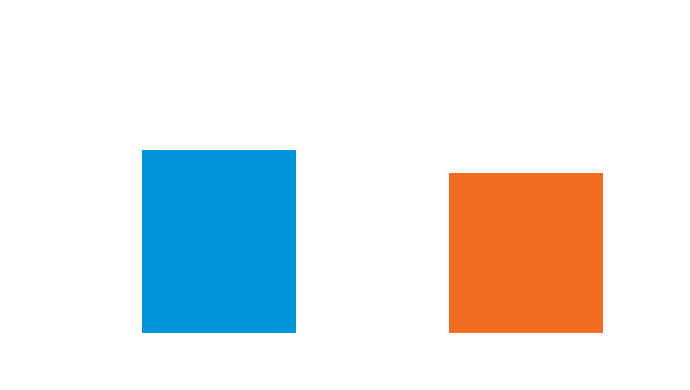

In [9]:
# using transparent background for poster

color_map = {
    "Male": "#0393DB",
    "Female": "#F26B21"
}

bar_colors = [color_map.get(label, "#999999") for label in sex_rates.index]

fig, ax = plt.subplots(figsize=(7, 4))

sex_rates["actual_employment_rate"].plot(
    kind="bar",
    ax=ax,
    color=bar_colors
)

# Text color
ax.set_title("Actual Employment Rate by Sex in the Dataset", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Sex", color="white", fontsize=12)
ax.set_ylabel("Employment Rate", color="white", fontsize=12)

# Tick colors
ax.tick_params(axis="x", colors="white", rotation=0)
ax.tick_params(axis="y", colors="white")

# Axis/spine colors
for spine in ax.spines.values():
    spine.set_color("white")

# grid
ax.grid(axis="y", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Transparent backgrounds
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.ylim(0, 1)
plt.tight_layout()

# Save as
plt.savefig(
    FIGURE_DIR / "actual_employment_by_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 8. Prepare modeling data


In [10]:
MAX_ROWS = 60000

if len(df) > MAX_ROWS:
    df_model = (
        df.groupby("employment", group_keys=False)
          .apply(lambda x: x.sample(
              n=min(len(x), max(1, int(MAX_ROWS * len(x) / len(df)))),
              random_state=RANDOM_STATE
          ))
          .sample(frac=1, random_state=RANDOM_STATE)
          .copy()
    )
else:
    df_model = df.copy()

print("Modeling dataset shape:", df_model.shape)
display(df_model["employment"].value_counts(normalize=True).to_frame("proportion"))

Modeling dataset shape: (59999, 20)


,proportion
employment,
1,0.571343
0,0.428657


## 9. Define features

This first model includes sex and race so we can audit how the model uses sensitive attributes. Then, a second model will be trained that removes sex to examine whether gendered prediction gaps remain through proxy variables.

In [11]:
numeric_features = ["age", "education"]

categorical_features_with_sex = [
    "marital_status",
    "relationship",
    "disability",
    "employment_status_parent",
    "citizenship_label",
    "mobility_status",
    "military_service",
    "ancestry",
    "nativity",
    "hearing_difficulty",
    "vision_difficulty",
    "cognitive_difficulty",
    "sex_label",
    "race_label"
]

features_with_sex = numeric_features + categorical_features_with_sex

target_col = "employment"

model_data = df_model[features_with_sex + [target_col]].copy()

# Treat coded ACS fields as categories
for col in categorical_features_with_sex:
    model_data[col] = model_data[col].astype(str)

X = model_data[features_with_sex]
y = model_data[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (47999, 16)
Test shape: (12000, 16)


## 10. Helper functions


In [12]:
def make_onehot_encoder():
    """
    Handles scikit-learn version differences.
    Newer versions use sparse_output; older versions use sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_pipeline(numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    classifier = RandomForestClassifier(
        n_estimators=150,
        max_depth=9,
        min_samples_leaf=25,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ])

    return model


def clean_feature_name(name):
    """Make transformed feature names easier to read in plots."""
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    name = name.replace("_", " ")
    return name


def transform_to_dataframe(model, X_input):
    """Apply the model preprocessor and return a dense DataFrame with readable feature names."""
    preprocessor = model.named_steps["preprocessor"]
    transformed = preprocessor.transform(X_input)

    if hasattr(transformed, "toarray"):
        transformed = transformed.toarray()

    feature_names = [clean_feature_name(n) for n in preprocessor.get_feature_names_out()]
    return pd.DataFrame(transformed, columns=feature_names, index=X_input.index)


def summarize_group_predictions(model, X_input, y_true, group_series, group_name="group"):
    """Summarize actual and predicted outcomes by a demographic group."""
    proba = model.predict_proba(X_input)[:, 1]
    pred = (proba >= 0.50).astype(int)

    results = pd.DataFrame({
        group_name: group_series.values,
        "actual": np.array(y_true),
        "predicted": pred,
        "predicted_probability": proba
    }, index=X_input.index)

    summary = (
        results.groupby(group_name)
        .agg(
            n=("actual", "size"),
            actual_employment_rate=("actual", "mean"),
            predicted_employment_rate=("predicted", "mean"),
            mean_predicted_probability=("predicted_probability", "mean")
        )
        .sort_values("predicted_employment_rate", ascending=False)
    )

    return summary, results


def get_positive_class_shap_values(explainer, X_transformed_df):
    """Return SHAP values for the positive class across SHAP versions."""
    raw_values = explainer.shap_values(X_transformed_df, check_additivity=False)

    if isinstance(raw_values, list):
        shap_values = raw_values[1]
    elif hasattr(raw_values, "ndim") and raw_values.ndim == 3:
        shap_values = raw_values[:, :, 1]
    else:
        shap_values = raw_values

    return shap_values


def get_positive_class_base_value(explainer):
    """Return expected/base value for the positive class."""
    base_value = explainer.expected_value

    if isinstance(base_value, (list, np.ndarray)) and np.array(base_value).ndim > 0:
        return base_value[1]
    return base_value


def disparate_impact_ratio(summary_table, protected_group="Female", reference_group="Male", rate_col="predicted_employment_rate"):
    """
    Compute a simple disparate impact ratio:
    protected group selection rate / reference group selection rate.
    """
    if protected_group not in summary_table.index or reference_group not in summary_table.index:
        return np.nan

    ref_rate = summary_table.loc[reference_group, rate_col]
    protected_rate = summary_table.loc[protected_group, rate_col]

    if ref_rate == 0:
        return np.nan

    return protected_rate / ref_rate

## 11. Train Model A: includes sex and race

Please note that this model is not meant to be a deployable hiring system. The purpose is to gain insight into what the model learns when sensitive attributes and historically patterned variables are included

In [13]:
model_with_sex = build_pipeline(numeric_features, categorical_features_with_sex)
model_with_sex.fit(X_train, y_train)

y_pred = model_with_sex.predict(X_test)
y_proba = model_with_sex.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Not employed", "Employed"]))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7763

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.69      0.73      5144
    Employed       0.78      0.84      0.81      6856

    accuracy                           0.78     12000
   macro avg       0.77      0.77      0.77     12000
weighted avg       0.78      0.78      0.77     12000


Confusion matrix:
[[3549 1595]
 [1089 5767]]


## 12. Predicted employment rates by sex

This table compares actual employment rates, predicted employment rates, and average predicted probabilities by sex. It is important to note that a gap here does not automatically prove discrimination. It shows that the model is reproducing group-patterned differences in the data.

In [14]:
sex_summary_with_sex, sex_results_with_sex = summarize_group_predictions(
    model_with_sex,
    X_test,
    y_test,
    X_test["sex_label"],
    group_name="sex"
)

display(sex_summary_with_sex)

di_with_sex = disparate_impact_ratio(sex_summary_with_sex, protected_group="Female", reference_group="Male")
print(f"Disparate impact ratio, Female / Male predicted employment rate: {di_with_sex:.3f}")

,n,actual_employment_rate,predicted_employment_rate,mean_predicted_probability
sex,,,,
Male,5908,0.611544,0.630162,0.544851
Female,6092,0.532337,0.597341,0.492298


Disparate impact ratio, Female / Male predicted employment rate: 0.948


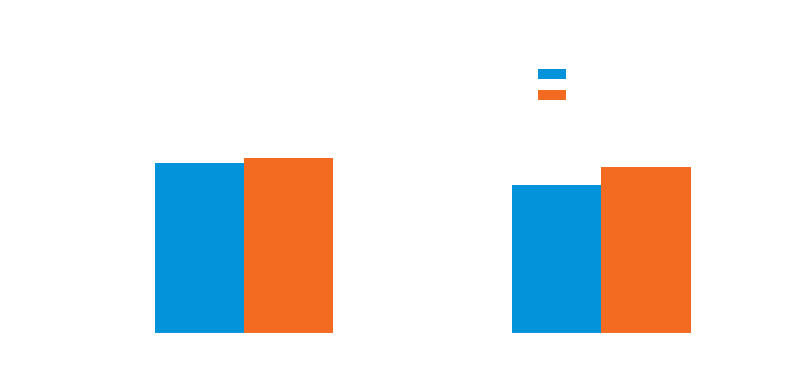

In [15]:
# This visualization isre-formatted for the poster presentation (same visualization as above)

# Poster colors
actual_color = "#0393DB"
predicted_color = "#F26B21"

fig, ax = plt.subplots(figsize=(8, 4))

sex_summary_with_sex[["actual_employment_rate", "predicted_employment_rate"]].plot(
    kind="bar",
    ax=ax,
    color=[actual_color, predicted_color]
)

# Title and labels
ax.set_title(
    "Actual vs. Predicted Employment Rate by Sex\nModel Includes Sex",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Sex", color="white", fontsize=12)
ax.set_ylabel("Rate", color="white", fontsize=12)

# Axis/tick formatting
ax.tick_params(axis="x", colors="white", rotation=0)
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

# Grid
ax.grid(axis="y", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Legend formatting
legend = ax.legend(
    ["Actual employment rate", "Predicted employment rate"],
    frameon=False,
    fontsize=10
)

for text in legend.get_texts():
    text.set_color("white")

# add percentage labels above bars
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.1f}%" for v in container],
        color="white",
        fontsize=9,
        padding=3
    )

# Transparent backgrounds
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.ylim(0, 1)
plt.tight_layout()

# Save
plt.savefig(
    FIGURE_DIR / "actual_vs_predicted_by_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 13. Intersectional view: predicted employment by sex and race

This table gives a more nuanced view than sex alone. This matters because gender does not operate in isolation. Gendered labor-market inequality often intersects with race, disability, citizenship, age, and other social structures.

In [16]:
intersection_results = pd.DataFrame({
    "sex": X_test["sex_label"].values,
    "race": X_test["race_label"].values,
    "actual": y_test.values,
    "predicted": y_pred,
    "predicted_probability": y_proba
}, index=X_test.index)

intersection_summary = (
    intersection_results
    .groupby(["sex", "race"])
    .agg(
        n=("actual", "size"),
        actual_employment_rate=("actual", "mean"),
        predicted_employment_rate=("predicted", "mean"),
        mean_predicted_probability=("predicted_probability", "mean")
    )
    .query("n >= 100")
    .sort_values("predicted_employment_rate", ascending=False)
)

display(intersection_summary)

n  actual_employment_rate  predicted_employment_rate  mean_predicted_probability
sex    race                                                                                                  
Male   Other               955                0.637696                   0.707853                    0.563831
       Asian              1022                0.650685                   0.683953                    0.589952
Female Other               952                0.546218                   0.671218                    0.506105
Male   Two or more races   974                0.629363                   0.668378                    0.557525
Female Asian              1230                0.569106                   0.662602                    0.521610
       Two or more races   967                0.573940                   0.632885                    0.502817
Male   White              2563                0.591494                   0.576668                    0.522708
       Black               256                0.500000                   0.531250                    0.477622
Female Black               258                0.461240                   0.527132                    0.452777
       White              2575                0.500194                   0.526602                    0.470675

## 18. Train Model B: remove sex from the model

Removing sex from the model is not enough to guarantee fairness as a model's inductive bias can still learn bias from the proxy variables. Next, I will train a second model that excludes sex but still evaluates outcomes by sex. The results suggests other variables may function as proxies for gendered opportunity structures.

In [17]:
categorical_features_no_sex = [c for c in categorical_features_with_sex if c != "sex_label"]
features_no_sex = numeric_features + categorical_features_no_sex

model_data_no_sex = df_model[features_no_sex + ["sex_label", target_col]].copy()

for col in categorical_features_no_sex:
    model_data_no_sex[col] = model_data_no_sex[col].astype(str)

X_no_sex = model_data_no_sex[features_no_sex]
y_no_sex = model_data_no_sex[target_col].astype(int)

X_train_no_sex, X_test_no_sex, y_train_no_sex, y_test_no_sex = train_test_split(
    X_no_sex,
    y_no_sex,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_no_sex
)

model_no_sex = build_pipeline(numeric_features, categorical_features_no_sex)
model_no_sex.fit(X_train_no_sex, y_train_no_sex)

y_pred_no_sex = model_no_sex.predict(X_test_no_sex)

print("Accuracy without sex:", round(accuracy_score(y_test_no_sex, y_pred_no_sex), 4))
print("\nClassification report:")
print(classification_report(y_test_no_sex, y_pred_no_sex, target_names=["Not employed", "Employed"]))

Accuracy without sex: 0.7742

Classification report:
              precision    recall  f1-score   support

Not employed       0.77      0.67      0.72      5144
    Employed       0.77      0.85      0.81      6856

    accuracy                           0.77     12000
   macro avg       0.77      0.76      0.76     12000
weighted avg       0.77      0.77      0.77     12000



## 19. Does the prediction gap remain after removing sex?

Even though sex from the model features, we can still use sex as an auditing variable to compare outcomes.

It is important to remember that bias can persist through proxy variables even when a protected attribute is removed.

In [18]:
sex_group_no_sex = df_model.loc[X_test_no_sex.index, "sex_label"]

sex_summary_no_sex, sex_results_no_sex = summarize_group_predictions(
    model_no_sex,
    X_test_no_sex,
    y_test_no_sex,
    sex_group_no_sex,
    group_name="sex"
)

display(sex_summary_no_sex)

di_no_sex = disparate_impact_ratio(sex_summary_no_sex, protected_group="Female", reference_group="Male")
print(f"Disparate impact ratio, Female / Male predicted employment rate, no-sex model: {di_no_sex:.3f}")

,n,actual_employment_rate,predicted_employment_rate,mean_predicted_probability
sex,,,,
Male,5908,0.611544,0.635071,0.518687
Female,6092,0.532337,0.625082,0.515610


Disparate impact ratio, Female / Male predicted employment rate, no-sex model: 0.984


,Model A: includes sex,Model B: excludes sex
sex,,
Male,0.630162,0.635071
Female,0.597341,0.625082


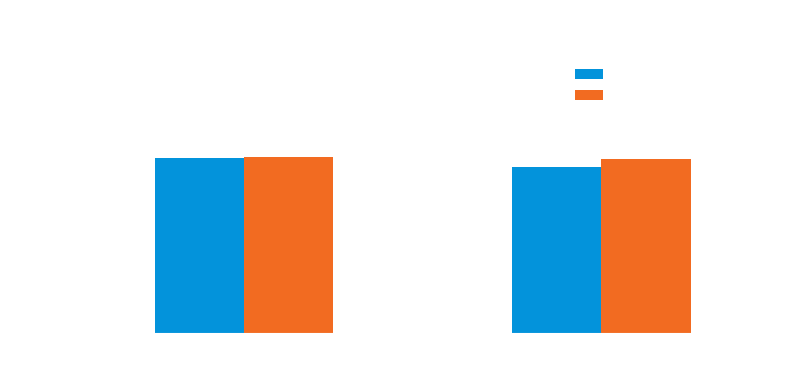

In [31]:
# comparison of prediction rates with and without sex
comparison = pd.concat(
    {
        "Model A: includes sex": sex_summary_with_sex["predicted_employment_rate"],
        "Model B: excludes sex": sex_summary_no_sex["predicted_employment_rate"]
    },
    axis=1
)

display(comparison)

fig, ax = plt.subplots(figsize=(8, 4))

comparison.plot(
    kind="bar",
    ax=ax,
    color=[POSTER_BLUE, POSTER_ORANGE]
)

ax.set_title(
    "Predicted Employment Rate by Sex\nWith vs. Without Sex Feature",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Sex", color="white", fontsize=12)
ax.set_ylabel("Predicted Employment Rate", color="white", fontsize=12)

ax.tick_params(axis="x", colors="white", rotation=0)
ax.tick_params(axis="y", colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

legend = ax.legend(frameon=False, fontsize=10)
for text in legend.get_texts():
    text.set_color("white")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{v.get_height()*100:.1f}%" for v in container],
        color="white",
        fontsize=9,
        padding=3
    )

ax.grid(axis="y", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.ylim(0, 1)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "predicted_employment_with_vs_without_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 14. SHAP global explanation

SHAP helps us inspect which features were most influential across many model predictions.

In [21]:
X_test_transformed = transform_to_dataframe(model_with_sex, X_test)

SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed))
X_shap = X_test_transformed.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)

rf_classifier = model_with_sex.named_steps["classifier"]
tree_explainer = shap.TreeExplainer(rf_classifier)

shap_values = get_positive_class_shap_values(tree_explainer, X_shap)

print("SHAP sample shape:", X_shap.shape)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP sample shape: (1000, 73)
SHAP values shape: (1000, 73)


In [22]:
# Mean absolute SHAP importance
shap_importance = (
    pd.DataFrame({
        "feature": X_shap.columns,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance.head(20))

,feature,mean_abs_shap
0,age,0.114832
1,education,0.029384
26,disability 1,0.027835
27,disability 2,0.026161
7,relationship 20,0.015284
62,sex label Female,0.012996
63,sex label Male,0.011150
3,marital status 2,0.009122
36,employment status parent nan,0.008276
61,cognitive difficulty 2.0,0.007623


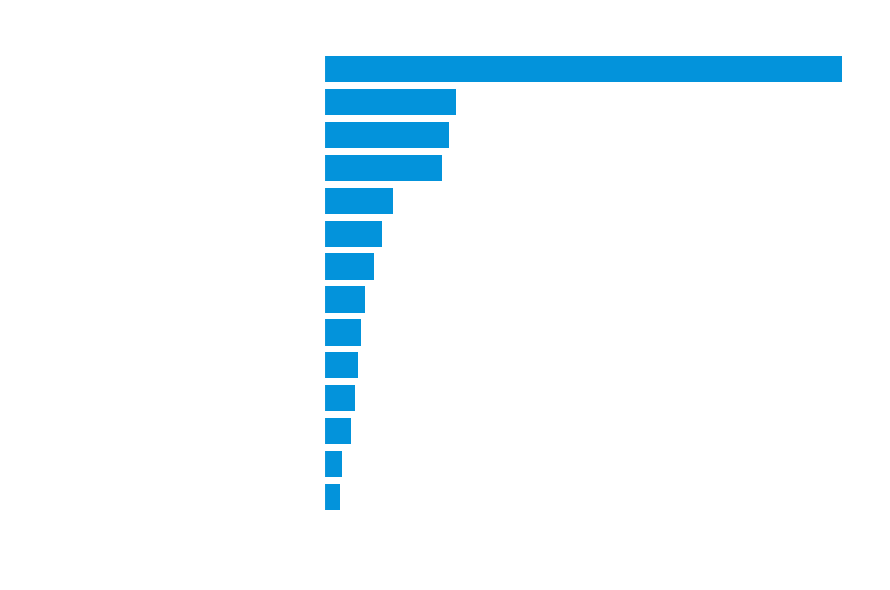

In [23]:
# Re-formatted

top_n = 14

feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "disability 1": "Has a disability",
    "disability 2": "No disability",

    "relationship 20": "Relationship: reference person",
    "relationship 25": "Relationship: biological child",
    "relationship 37": "Relationship: foster child",
    "relationship 38": "Relationship: other nonrelative",

    "sex label Female": "Sex: female",
    "sex label Male": "Sex: male",

    "marital status 1": "Marital status: married",
    "marital status 2": "Marital status: widowed",
    "marital status 5": "Marital status: never married",

    "employment status parent nan": "Parental employment status: not applicable",

    "cognitive difficulty 1.0": "Has cognitive difficulty",
    "cognitive difficulty 2.0": "No cognitive difficulty",

    "race label White": "Race: White"
}

plot_data = (
    shap_importance
    .head(top_n)
    .copy()
)

plot_data["feature_label"] = (
    plot_data["feature"]
    .map(feature_label_map)
    .fillna(plot_data["feature"])
)

plot_data = plot_data.sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(9, 6))

ax.barh(
    plot_data["feature_label"],
    plot_data["mean_abs_shap"],
    color="#0393DB"
)

ax.set_title(
    "Top SHAP Features — Model Includes Sex",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Mean |SHAP value|", color="white", fontsize=12)
ax.set_ylabel("")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white", labelsize=10)

for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(axis="x", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_14_shap_features_model_includes_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

### SHAP beeswarm plot

The beeswarm plot shows both feature importance and direction.

- Points to the right push predictions toward **employed**.
- Points to the left push predictions toward **not employed**.
- The feature value color shows whether a value is high or low after preprocessing.

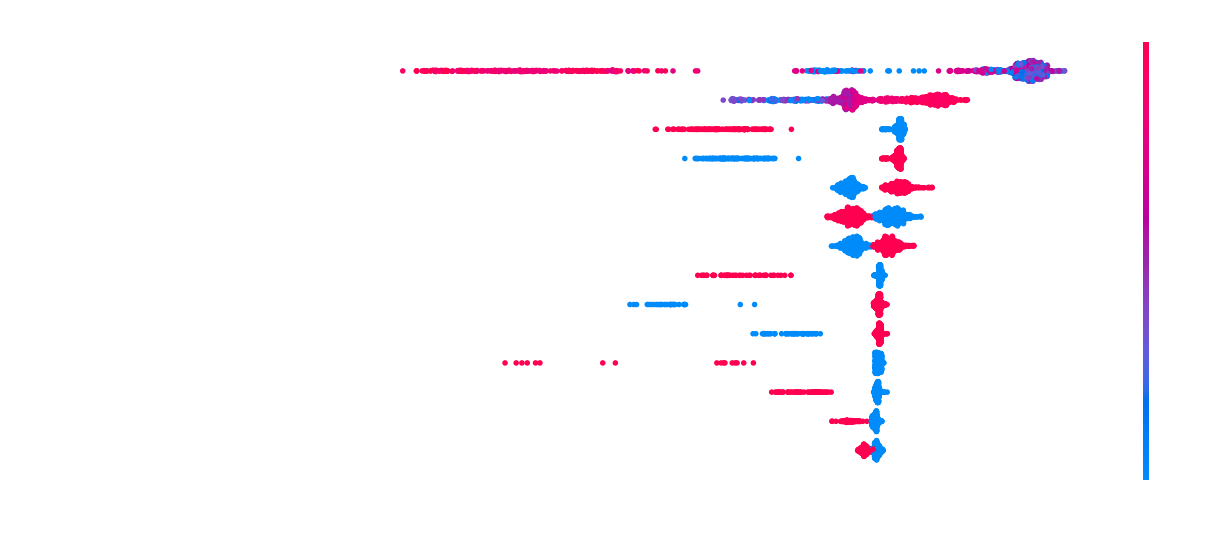

In [24]:
# labels
feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "disability 1": "Disability: Yes",
    "disability 2": "Disability: No",

    "sex label Female": "Sex: Female",
    "sex label Male": "Sex: Male",

    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",

    "employment status parent nan": "Parental employment status: Not available",

    "cognitive difficulty 1.0": "Cognitive difficulty: Yes",
    "cognitive difficulty 2.0": "Cognitive difficulty: No",

    "race label White": "Race: White",

    "relationship 20": "Relationship category 20",
    "relationship 25": "Relationship category 25",
    "relationship 37": "Relationship category 37",
    "relationship 38": "Relationship category 38",

    "military service 4.0": "Military service category 4",
    "military service nan": "Military service: Not available"
}

# Rename columns
X_shap_plot = X_shap.copy()
X_shap_plot.columns = [feature_label_map.get(col, col) for col in X_shap_plot.columns]

# Wider  beeswarm
shap.summary_plot(
    shap_values,
    X_shap_plot,
    max_display=14,
    show=False,
    plot_size=(14, 6)
)

fig = plt.gcf()
ax = plt.gca()

ax.set_title(
    "SHAP Beeswarm — Model Includes Sex",
    color="white",
    fontsize=16,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("SHAP value impact on model output", color="white", fontsize=12)


ax.tick_params(axis="x", colors="white", labelsize=10)
ax.tick_params(axis="y", colors="white", labelsize=11)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# Make grid / zero line work on dark background
for line in ax.lines:
    line.set_color("white")
    line.set_alpha(0.35)

for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.4)

# Format colorbar
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(colors="white", labelsize=10)
    cbar_ax.yaxis.label.set_color("white")
    cbar_ax.yaxis.label.set_size(12)

    for spine in cbar_ax.spines.values():
        spine.set_color("white")

# Giving long y-axis labels more room
plt.subplots_adjust(left=0.28, right=0.93, top=0.88, bottom=0.15)

plt.savefig(
    FIGURE_DIR / "shap_beeswarm_model_includes_sex_wide_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

## 20. SHAP on the no-sex model

This final SHAP analysis helps identify which variables may be carrying predictive power after sex is removed. There are some proxy variables here that may initially appear neutral but still reflect gendered histories of labor-market access.


In [25]:
X_test_no_sex_transformed = transform_to_dataframe(model_no_sex, X_test_no_sex)

SHAP_SAMPLE_SIZE_NO_SEX = min(1000, len(X_test_no_sex_transformed))
X_shap_no_sex = X_test_no_sex_transformed.sample(SHAP_SAMPLE_SIZE_NO_SEX, random_state=RANDOM_STATE)

rf_classifier_no_sex = model_no_sex.named_steps["classifier"]
tree_explainer_no_sex = shap.TreeExplainer(rf_classifier_no_sex)

shap_values_no_sex = get_positive_class_shap_values(tree_explainer_no_sex, X_shap_no_sex)

shap_importance_no_sex = (
    pd.DataFrame({
        "feature": X_shap_no_sex.columns,
        "mean_abs_shap": np.abs(shap_values_no_sex).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

display(shap_importance_no_sex.head(20))

,feature,mean_abs_shap
0,age,0.101644
26,disability 1,0.031856
1,education,0.031249
27,disability 2,0.026374
7,relationship 20,0.015544
3,marital status 2,0.010519
24,relationship 37,0.009671
36,employment status parent nan,0.009302
61,cognitive difficulty 2.0,0.006629
70,race label White,0.004846


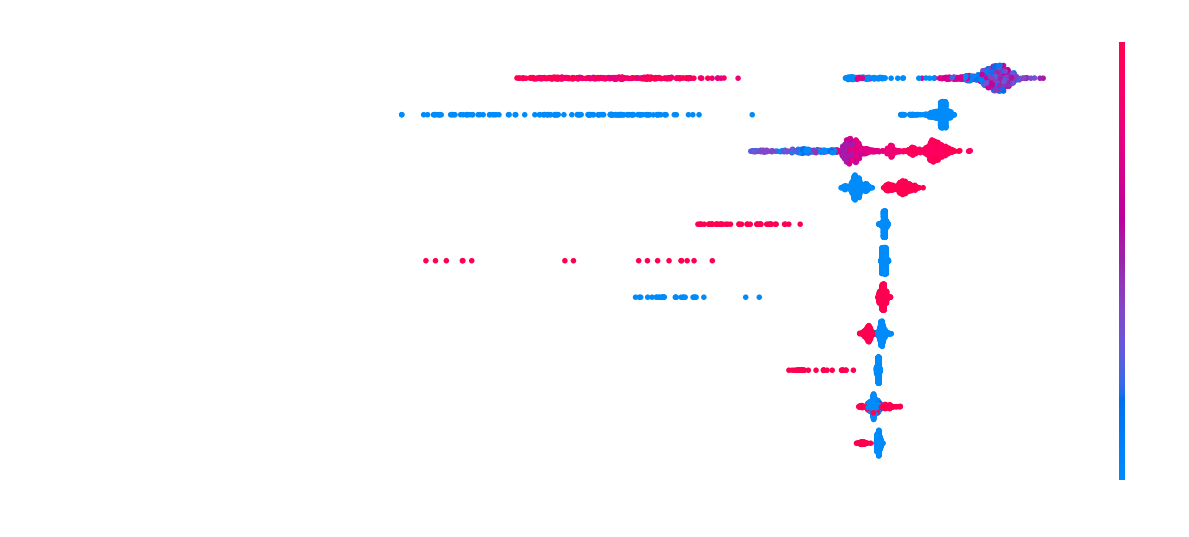

In [26]:

if not isinstance(X_shap_no_sex, pd.DataFrame):
    X_shap_no_sex = pd.DataFrame(X_shap_no_sex)

# Make a SHAP DataFrame
shap_df = pd.DataFrame(
    shap_values_no_sex,
    columns=X_shap_no_sex.columns,
    index=X_shap_no_sex.index
)


# Group disability-related features together
def group_feature_name(col):
    col_lower = str(col).lower()

    if (
        "disability" in col_lower
        or "cognitive difficulty" in col_lower
        or "hearing difficulty" in col_lower
        or "vision difficulty" in col_lower
    ):
        return "Disability-related factors"

    return col

group_labels = [group_feature_name(col) for col in shap_df.columns]

# Aggregate SHAP values by grouped feature name
shap_grouped = shap_df.T.groupby(group_labels).sum().T

# Aggregate feature values for plotting/color
X_grouped = pd.DataFrame(index=X_shap_no_sex.index)

for group_name in pd.unique(group_labels):
    cols_in_group = [col for col, grp in zip(X_shap_no_sex.columns, group_labels) if grp == group_name]

    if group_name == "Disability-related factors":

        X_grouped[group_name] = X_shap_no_sex[cols_in_group].max(axis=1)
    else:
        X_grouped[group_name] = X_shap_no_sex[cols_in_group[0]]


feature_label_map = {
    "age": "Age",
    "education": "Educational attainment",

    "relationship 20": "Relationship category 20",
    "relationship 25": "Relationship category 25",
    "relationship 37": "Relationship category 37",
    "relationship 38": "Relationship category 38",

    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",

    "employment status parent nan": "Parental employment status: Not available",
    "employment status parent 1.0": "Parental employment status: Employed",

    "race label White": "Race: White",

    "military service 4.0": "Military service category 4",
    "military service nan": "Military service: Not available",

    "citizenship label": "Citizenship",
    "mobility status": "Mobility status",
    "ancestry": "Ancestry",
    "nativity": "Nativity",

    "Disability-related factors": "Disability-related factors"
}

# Rename columns for display
shap_grouped = shap_grouped.rename(columns=feature_label_map)
X_grouped = X_grouped.rename(columns=feature_label_map)

# -----------------------------
# Keep only top 11 features
# -----------------------------
top_11_features = (
    shap_grouped.abs()
    .mean()
    .sort_values(ascending=False)
    .head(11)
    .index
    .tolist()
)

shap_top = shap_grouped[top_11_features]
X_top = X_grouped[top_11_features]

# Create poster-friendly beeswarm
shap.summary_plot(
    shap_top.values,
    X_top,
    max_display=11,
    show=False,
    plot_size=(14, 6)   # wider plot so the beeswarms are less scrunched
)

fig = plt.gcf()
ax = plt.gca()

# Title and labels
ax.set_title(
    "SHAP Beeswarm — Model Excludes Sex",
    color="white",
    fontsize=16,
    fontweight="bold",
    pad=12
)
ax.set_xlabel("SHAP value impact on model output", color="white", fontsize=12)

# White tick labels
ax.tick_params(axis="x", colors="white", labelsize=10)
ax.tick_params(axis="y", colors="white", labelsize=11)

# Transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# White spines
for spine in ax.spines.values():
    spine.set_color("white")
    spine.set_alpha(0.4)

# Make the zero/reference line easier to see on dark background
for line in ax.lines:
    line.set_color("white")
    line.set_alpha(0.35)

# Colorbar formatting
if len(fig.axes) > 1:
    cbar_ax = fig.axes[-1]
    cbar_ax.tick_params(colors="white", labelsize=10)
    cbar_ax.yaxis.label.set_color("white")
    cbar_ax.yaxis.label.set_size(12)
    for spine in cbar_ax.spines.values():
        spine.set_color("white")

# Give the y-axis labels more room
plt.subplots_adjust(left=0.30, right=0.93, top=0.88, bottom=0.15)

# Save transparent PNG
plt.savefig(
    FIGURE_DIR / "shap_beeswarm_model_excludes_sex_top11_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

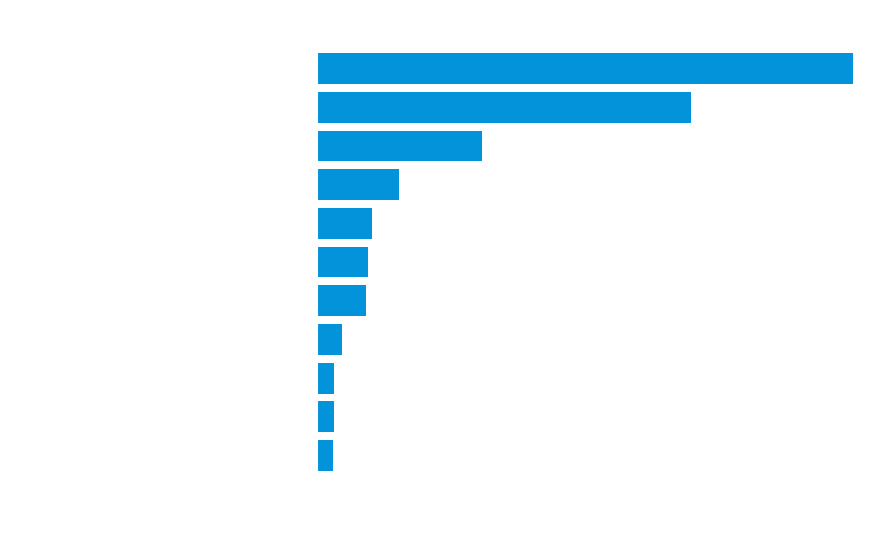

In [27]:
# Optional poster-friendly top feature bar chart for the no-sex model
# This groups disability-related factors before ranking.
shap_df_no_sex = pd.DataFrame(
    shap_values_no_sex,
    columns=X_shap_no_sex.columns,
    index=X_shap_no_sex.index
)

def group_feature_name_for_display(col):
    col_lower = str(col).lower()
    if (
        "disability" in col_lower
        or "cognitive difficulty" in col_lower
        or "hearing difficulty" in col_lower
        or "vision difficulty" in col_lower
    ):
        return "Disability-related factors"
    return col

group_labels_no_sex = [group_feature_name_for_display(col) for col in shap_df_no_sex.columns]
shap_grouped_no_sex = shap_df_no_sex.T.groupby(group_labels_no_sex).sum().T

feature_label_map_no_sex = {
    "age": "Age",
    "education": "Educational attainment",
    "relationship 20": "Relationship category 20",
    "relationship 25": "Relationship category 25",
    "relationship 37": "Relationship category 37",
    "relationship 38": "Relationship category 38",
    "marital status 1": "Marital status: Married",
    "marital status 2": "Marital status: Widowed",
    "marital status 5": "Marital status: Never married",
    "employment status parent nan": "Parental employment status: Not available",
    "employment status parent 1.0": "Parental employment status: Employed",
    "race label White": "Race: White",
    "military service 4.0": "Military service category 4",
    "military service nan": "Military service: Not available",
    "Disability-related factors": "Disability-related factors"
}

shap_importance_no_sex_grouped = (
    pd.DataFrame({
        "feature": shap_grouped_no_sex.columns,
        "mean_abs_shap": shap_grouped_no_sex.abs().mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
)

plot_data = shap_importance_no_sex_grouped.head(11).copy()
plot_data["feature_label"] = plot_data["feature"].map(feature_label_map_no_sex).fillna(plot_data["feature"])
plot_data = plot_data.sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(9, 5.6))

ax.barh(
    plot_data["feature_label"],
    plot_data["mean_abs_shap"],
    color=POSTER_BLUE
)

ax.set_title(
    "Top SHAP Features — Model Excludes Sex",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Mean |SHAP value|", color="white", fontsize=12)
ax.set_ylabel("")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white", labelsize=10)

for spine in ax.spines.values():
    spine.set_color("white")

ax.grid(axis="x", color="white", alpha=0.20, linestyle="--")
ax.set_axisbelow(True)

fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "top_11_shap_features_model_excludes_sex_transparent.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()


In [28]:
X_test_transformed = transform_to_dataframe(model_with_sex, X_test)
SHAP_SAMPLE_SIZE = min(1000, len(X_test_transformed))
X_shap = X_test_transformed.sample(SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
rf_classifier = model_with_sex.named_steps["classifier"]

print("Transformed test sample shape:", X_shap.shape)


Transformed test sample shape: (1000, 73)


## 16. LIME local explanation

LIME explains one prediction by approximating the model locally around that case and is applied to the preprocessed one-hot encoded feature space.

LIME explanation as list:
relationship 37 <= 0.00: 0.1609
disability 1 <= 0.00: 0.1164
military service nan <= 0.00: 0.1132
employment status parent 7.0 <= 0.00: 0.0984
age <= -0.85: 0.0905
marital status 2 <= 0.00: 0.0845
race label Alaska Native <= 0.00: -0.0789
relationship 26 <= 0.00: 0.0730
employment status parent 3.0 <= 0.00: 0.0662
citizenship label Born in Puerto Rico / U.S. Island Areas <= 0.00: 0.0642


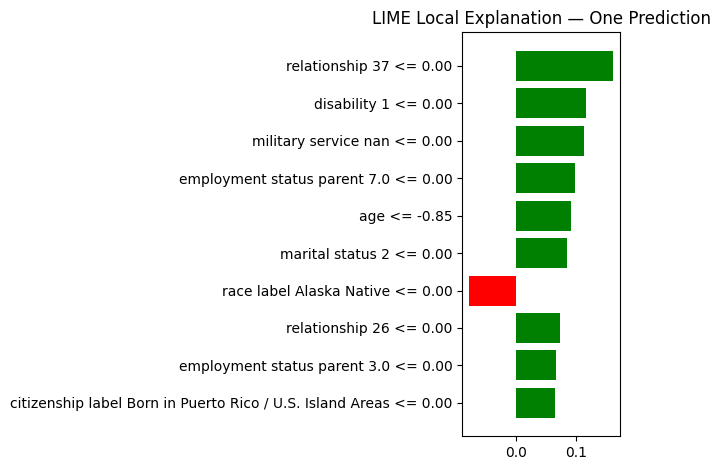

In [29]:
LIME_TRAIN_SIZE = min(5000, len(X_test_transformed))
lime_background = X_test_transformed.sample(LIME_TRAIN_SIZE, random_state=RANDOM_STATE)

lime_explainer = LimeTabularExplainer(
    training_data=lime_background.values,
    feature_names=lime_background.columns.tolist(),
    class_names=["Not employed", "Employed"],
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

def lime_predict_proba(transformed_array):
    return rf_classifier.predict_proba(transformed_array)

lime_case_index = 0
lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.iloc[lime_case_index].values,
    predict_fn=lime_predict_proba,
    num_features=10
)

print("LIME explanation as list:")
for feature, weight in lime_exp.as_list():
    print(f"{feature}: {weight:.4f}")

fig = lime_exp.as_pyplot_figure()
plt.title("LIME Local Explanation — One Prediction")
plt.tight_layout()
plt.show()


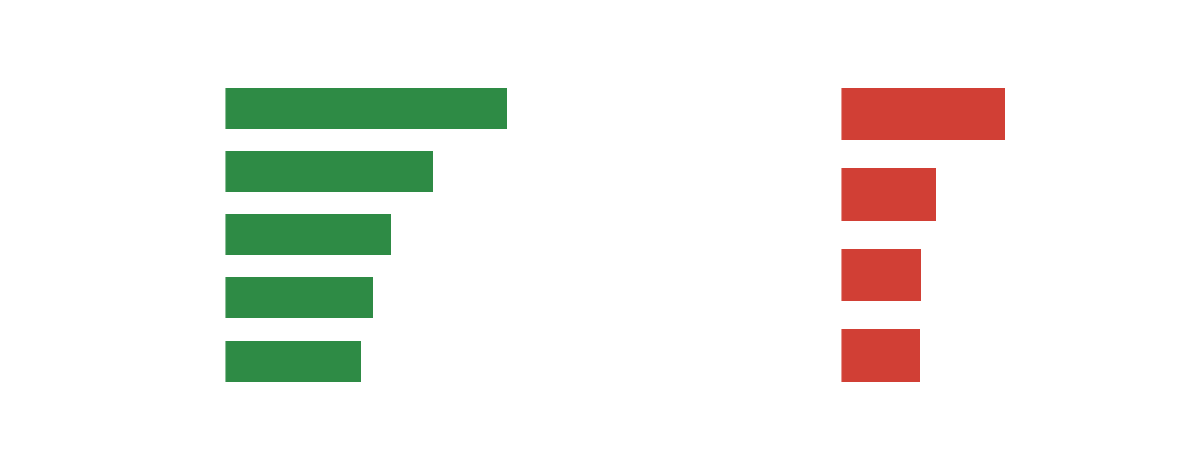

In [30]:
lime_exp = lime_explainer.explain_instance(
    data_row=X_shap.iloc[lime_case_index].values,
    predict_fn=lime_predict_proba,
    num_features=14
)

lime_df = pd.DataFrame(
    lime_exp.as_list(),
    columns=["feature", "weight"]
)


# Clean feature labels

def clean_lime_label(label):
    label = str(label)

    replacements = {
        "Relationship 37 <= 0.00": "Relationship category 37",
        "Disability 1 <= 0.00": "Disability-related factor",
        "military service nan <= 0.00": "Military service: not available",
        "Parental employment status 7.0 <= 0.00": "Parental employment status",
        "Age <= -0.85": "Younger age group",
        "Race Alaska Native <= 0.00": "Race category: Alaska Native",
    }

    if label in replacements:
        return replacements[label]

    label = label.replace("num__", "")
    label = label.replace("cat__", "")
    label = label.replace("_", " ")

    label = label.replace("age", "Age")
    label = label.replace("education", "Education")
    label = label.replace("disability", "Disability")
    label = label.replace("relationship", "Relationship")
    label = label.replace("marital status", "Marital status")
    label = label.replace("military service", "Military service")
    label = label.replace("employment status parent", "Parental employment status")
    label = label.replace("race label", "Race")

    # Remove hard-to-read threshold notation
    label = label.replace(" <= 0.00", "")
    label = label.replace(" > 0.00", "")

    return label.strip().title()

lime_df["label"] = lime_df["feature"].apply(clean_lime_label)

# Split into positive and negative
positive = (
    lime_df[lime_df["weight"] > 0]
    .sort_values("weight", ascending=False)
    .head(5)
    .sort_values("weight", ascending=True)
)

negative = (
    lime_df[lime_df["weight"] < 0]
    .copy()
)

negative["abs_weight"] = negative["weight"].abs()

negative = (
    negative
    .sort_values("abs_weight", ascending=False)
    .head(5)
    .sort_values("abs_weight", ascending=True)
)


# Plot

fig, axes = plt.subplots(
    1, 2,
    figsize=(12.5, 4.2),
    gridspec_kw={"wspace": 0.75}
)

green = "#2E8B45"
red = "#D13F35"
white = "white"

# Left panel: positive
axes[0].barh(
    positive["label"],
    positive["weight"],
    color=green,
    height=0.65
)

axes[0].set_title(
    "Supports Employment\n(Increase Prediction)",
    color=white,
    fontsize=13,
    fontweight="bold"
)

for i, value in enumerate(positive["weight"]):
    axes[0].text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        color=white,
        fontsize=10,
        fontweight="bold"
    )

# Right panel: negative, plotted as absolute value for readability
axes[1].barh(
    negative["label"],
    negative["abs_weight"],
    color=red,
    height=0.65
)

axes[1].set_title(
    "Supports Not Employed\n(Decrease Prediction)",
    color=white,
    fontsize=13,
    fontweight="bold"
)

for i, row in enumerate(negative.itertuples()):
    axes[1].text(
        row.abs_weight + 0.01,
        i,
        f"{row.weight:.2f}",
        va="center",
        color=white,
        fontsize=10,
        fontweight="bold"
    )

# Formatting
max_value = max(
    positive["weight"].max() if len(positive) else 0,
    negative["abs_weight"].max() if len(negative) else 0
)

for ax in axes:
    ax.set_xlim(0, max_value * 1.25)

    ax.tick_params(axis="y", colors=white, labelsize=10)
    ax.tick_params(axis="x", colors=white, labelsize=9)

    ax.grid(axis="x", color=white, alpha=0.18, linestyle="--")
    ax.set_axisbelow(True)

    ax.set_facecolor("none")

    for spine in ax.spines.values():
        spine.set_color(white)
        spine.set_alpha(0.45)

# Overall title
fig.suptitle(
    "LIME Local Explanation — One Prediction",
    color=white,
    fontsize=17,
    fontweight="bold",
    y=1.03
)

fig.text(
    0.5,
    -0.02,
    "Prediction probability (Employed): 0.73",
    ha="center",
    color=white,
    fontsize=13,
    fontweight="bold"
)

# Transparent background
fig.patch.set_alpha(0)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "lime_local_explanation_poster_clean.png",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()